# Delivery Route Optimization — Genetic Algorithm

**Author:** De Silva T.H.H.H  
**Course:** Optimization Methods  
**Date:** April 2026

---

## 1. Introduction

We're solving the TSP for 15 UK cities finding the shortest route that visits each city once and returns to London. The approach here is a **Genetic Algorithm (GA)** instead of an exact method.

Dataset: [Travelling Salesman Problem: Visit 49 UK Cities](https://www.kaggle.com/datasets/patricklford/travelling-salesman-problem) (Kaggle, CC0). 15 cities selected from the full set.

### Why a metaheuristic?

ILP gives the exact optimal but its runtime blows up exponentially. For bigger problems (50+ cities) it becomes impractical. GA trades off guaranteed optimality for much better scalability it finds near optimal solutions in polynomial time.

### Why GA specifically?

- Maintains a population of solutions so it explores broadly
- Ordered Crossover (OX) works well with permutations keeps routes valid
- Mutation helps avoid getting stuck in local optima
- Time complexity is O(G x P x n) which is polynomial, unlike ILP

## 2. How GA Works

GA mimics natural selection. We start with a random population of candidate routes, then iterate:

1. **Evaluate** fitness (total distance) of each route
2. **Select** parents — tournament selection, pick 3 random ones, keep the best
3. **Crossover** — Ordered Crossover (OX) combines two parent routes into children
4. **Mutate** — randomly swap cities in some individuals
5. **Repeat** for many generations

Over time the population converges toward good solutions.

| GA Concept | TSP Meaning |
|------------|-------------|
| Chromosome | A permutation of cities (one route) |
| Gene | A single city in the route |
| Fitness | Total route distance (lower = better) |
| Selection | Tournament, k=3 |
| Crossover | Ordered Crossover (OX), prob=0.8 |
| Mutation | Shuffle/swap, prob=0.2 |

For 15 cities the search space is $(14)!/2 \approx 43$ billion routes. GA explores this efficiently without checking all of them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
import random
import time
import json
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load Kaggle dataset
df_full = pd.read_csv('../data/UK_Cities.csv')

selected_cities = [
    'London', 'Birmingham', 'Leeds', 'Glasgow', 'Sheffield',
    'Manchester', 'Liverpool', 'Edinburgh', 'Bristol', 'Cardiff',
    'Leicester', 'Nottingham', 'Newcastle upon Tyne', 'Southampton', 'Plymouth'
]
df = df_full[df_full['City'].isin(selected_cities)].reset_index(drop=True)

order = {city: i for i, city in enumerate(selected_cities)}
df['sort_order'] = df['City'].map(order)
df = df.sort_values('sort_order').reset_index(drop=True)
df = df.drop(columns=['sort_order'])

city_names = df['City'].tolist()
coords = df[['Latitude', 'Longitude']].values
n_cities = len(city_names)

print(f"{n_cities} cities loaded, depot = {city_names[0]}\n")
for i, row in df.iterrows():
    print(f"  {i:2d}. {row['City']:25s} ({row['Latitude']:.4f}, {row['Longitude']:.4f})")

15 cities loaded, depot = London

   0. London                    (51.5074, -0.1278)
   1. Birmingham                (52.4862, -1.8904)
   2. Leeds                     (53.8008, -1.5491)
   3. Glasgow                   (55.8642, -4.2518)
   4. Sheffield                 (53.3811, -1.4701)
   5. Manchester                (53.4808, -2.2426)
   6. Liverpool                 (53.4084, -2.9916)
   7. Edinburgh                 (55.9533, -3.1883)
   8. Bristol                   (51.4545, -2.5879)
   9. Cardiff                   (51.4816, -3.1791)
  10. Leicester                 (52.6369, -1.1398)
  11. Nottingham                (52.9548, -1.1581)
  12. Newcastle upon Tyne       (54.9783, -1.6174)
  13. Southampton               (50.9097, -1.4044)
  14. Plymouth                  (50.3755, -4.1427)


In [3]:
# Haversine distance matrix (km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

dist_matrix = np.zeros((n_cities, n_cities))
for i in range(n_cities):
    for j in range(n_cities):
        if i != j:
            dist_matrix[i][j] = haversine(
                coords[i][0], coords[i][1], coords[j][0], coords[j][1]
            )

dist_df = pd.DataFrame(dist_matrix, index=city_names, columns=city_names)
print("Distance matrix (first 8 cities):")
print(dist_df.iloc[:8, :8].round(2).to_string())
print(f"\nMax: {dist_matrix.max():.2f} km, Min (non-zero): {dist_matrix[dist_matrix > 0].min():.2f} km")

Distance matrix (first 8 cities):
            London  Birmingham   Leeds  Glasgow  Sheffield  Manchester  Liverpool  Edinburgh
London        0.00      162.50  272.43   555.15     227.33      261.98     286.89     533.65
Birmingham  162.50        0.00  147.94   405.78     103.42      113.08     126.33     394.63
Leeds       272.43      147.94    0.00   287.36      46.96       57.93     104.70     261.29
Glasgow     555.15      405.78  287.36     0.00     329.04      294.80     284.85      67.02
Sheffield   227.33      103.42   46.96   329.04       0.00       52.36     100.93     306.59
Manchester  261.98      113.08   57.93   294.80      52.36        0.00      50.25     281.55
Liverpool   286.89      126.33  104.70   284.85     100.93       50.25       0.00     283.26
Edinburgh   533.65      394.63  261.29    67.02     306.59      281.55     283.26       0.00

Max: 623.46 km, Min (non-zero): 35.37 km


## 3. Design Choices

**Representation:** Each chromosome is a permutation of city indices 1-14 (London/index 0 is always start and end). So every individual is automatically a valid tour.

**Fitness:** Total Haversine distance of the route. Lower is better.

**Selection:** Tournament with k=3. Gives decent selection pressure without killing diversity too fast.

**Crossover:** Ordered Crossover (OX), prob=0.8. This is important for TSP normal crossover would create invalid routes with duplicate cities. OX takes a segment from one parent and fills the rest from the other parent in order.

**Mutation:** Shuffle indexes with per-gene probability 0.05, overall mutation prob=0.2. Small random swaps to keep exploring.

| Parameter | Value |
|-----------|-------|
| Population | 200 |
| Generations | 500 |
| Crossover prob | 0.8 |
| Mutation prob | 0.2 |
| Tournament size | 3 |

In [4]:
def evaluate_tsp(individual, dist_matrix):
    """Total distance for a route: depot -> individual cities -> depot."""
    route = [0] + [x + 1 for x in individual] + [0]
    return (sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route) - 1)),)


def solve_tsp_ga(dist_matrix, city_names, pop_size=200, n_gen=500, 
                 cx_prob=0.8, mut_prob=0.2, seed=42):
    """Run GA to solve TSP. Returns best tour, distance, time, and logbook."""
    random.seed(seed)
    np.random.seed(seed)
    n = len(city_names)
    
    # DEAP setup
    if not hasattr(creator, "FitnessMin"):
        creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", list, fitness=creator.FitnessMin)
    
    toolbox = base.Toolbox()
    toolbox.register("indices", random.sample, range(n - 1), n - 1)
    toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate_tsp, dist_matrix=dist_matrix)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("mate", tools.cxOrdered)
    toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
    
    pop = toolbox.population(n=pop_size)
    
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    
    hof = tools.HallOfFame(1)
    
    start_time = time.time()
    pop, logbook = algorithms.eaSimple(
        pop, toolbox, cxpb=cx_prob, mutpb=mut_prob,
        ngen=n_gen, stats=stats, halloffame=hof, verbose=False
    )
    solve_time = time.time() - start_time
    
    best = hof[0]
    best_route = [0] + [x + 1 for x in best] + [0]
    
    return {
        'tour': best_route,
        'tour_names': [city_names[i] for i in best_route],
        'total_distance': best.fitness.values[0],
        'solve_time': solve_time,
        'logbook': logbook,
        'population_size': pop_size,
        'generations': n_gen
    }

In [5]:
# Cell 7: Run GA and Display Results

print("Running Genetic Algorithm for TSP...")
print("=" * 60)

ga_result = solve_tsp_ga(dist_matrix, city_names, 
                          pop_size=200, n_gen=500, 
                          cx_prob=0.8, mut_prob=0.2, seed=42)

print(f"\nGA Optimization Complete!")
print(f"{'=' * 60}")
print(f"\nBest Route Found:")
print(f"-" * 40)
for i, name in enumerate(ga_result['tour_names']):
    if i < len(ga_result['tour_names']) - 1:
        next_city = ga_result['tour'][i+1]
        curr_city = ga_result['tour'][i]
        leg_dist = dist_matrix[curr_city][next_city]
        print(f"  {i:2d}. {name:20s}  -> {leg_dist:.2f} km")
    else:
        print(f"  {i:2d}. {name:20s}  (return to depot)")

print(f"\n{'=' * 60}")
print(f"Total Distance : {ga_result['total_distance']:.2f} km")
print(f"Solve Time     : {ga_result['solve_time']:.4f} seconds")
print(f"Population     : {ga_result['population_size']}")
print(f"Generations    : {ga_result['generations']}")
print(f"Cities Visited : {len(ga_result['tour']) - 1} (+ return to depot)")

Running Genetic Algorithm for TSP...

GA Optimization Complete!

Best Route Found:
----------------------------------------
   0. London                -> 143.38 km
   1. Leicester             -> 119.31 km
   2. Manchester            -> 50.25 km
   3. Liverpool             -> 284.85 km
   4. Glasgow               -> 67.02 km
   5. Edinburgh             -> 146.82 km
   6. Newcastle upon Tyne   -> 131.01 km
   7. Leeds                 -> 46.96 km
   8. Sheffield             -> 51.76 km
   9. Nottingham            -> 71.75 km
  10. Birmingham            -> 124.27 km
  11. Bristol               -> 41.06 km
  12. Cardiff               -> 140.31 km
  13. Plymouth              -> 202.01 km
  14. Southampton           -> 111.02 km
  15. London                (return to depot)

Total Distance : 1731.78 km
Solve Time     : 4.9884 seconds
Population     : 200
Generations    : 500
Cities Visited : 15 (+ return to depot)


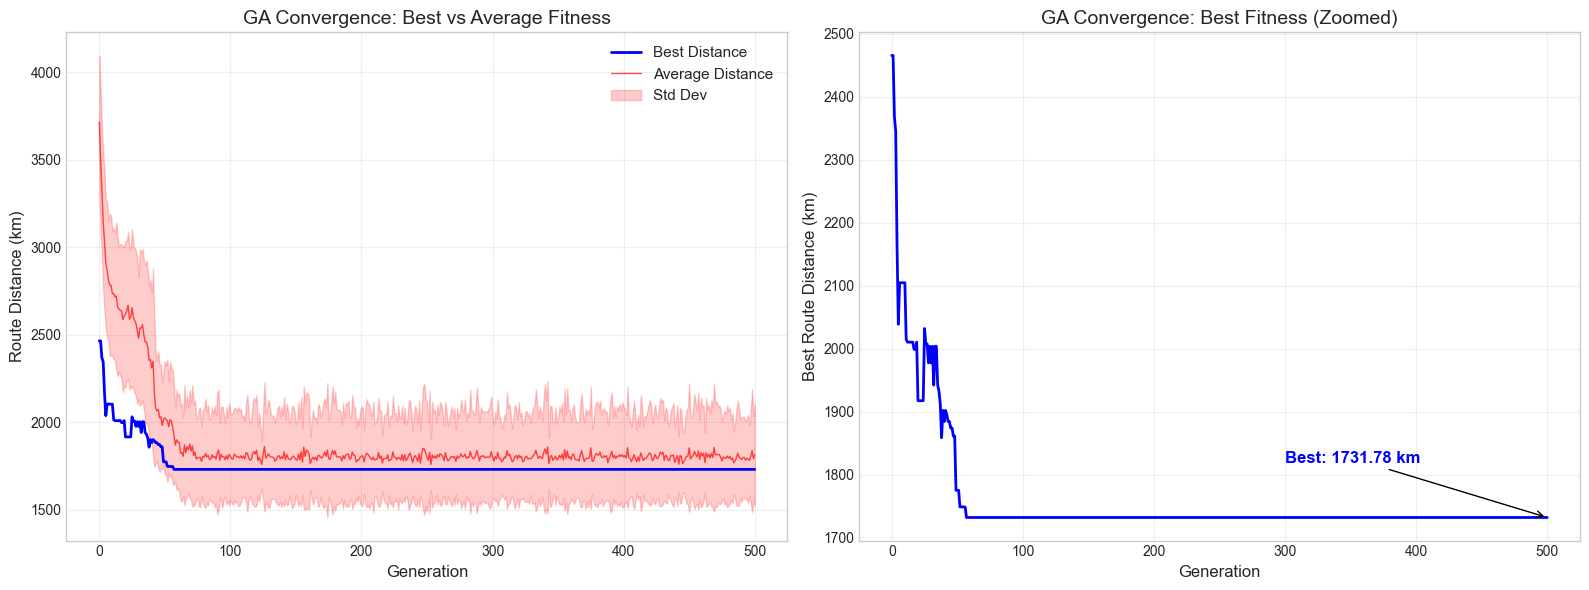

Convergence plot saved.


In [6]:
# Cell 8: Convergence Plot

gen = ga_result['logbook'].select("gen")
fit_min = ga_result['logbook'].select("min")
fit_avg = ga_result['logbook'].select("avg")
fit_std = ga_result['logbook'].select("std")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Best and Average Fitness over Generations
ax1.plot(gen, fit_min, 'b-', linewidth=2, label='Best Distance')
ax1.plot(gen, fit_avg, 'r-', linewidth=1, alpha=0.7, label='Average Distance')
ax1.fill_between(gen, 
                  np.array(fit_avg) - np.array(fit_std), 
                  np.array(fit_avg) + np.array(fit_std), 
                  alpha=0.2, color='red', label='Std Dev')
ax1.set_xlabel('Generation', fontsize=12)
ax1.set_ylabel('Route Distance (km)', fontsize=12)
ax1.set_title('GA Convergence: Best vs Average Fitness', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Zoomed-in view of best fitness convergence
ax2.plot(gen, fit_min, 'b-', linewidth=2)
ax2.set_xlabel('Generation', fontsize=12)
ax2.set_ylabel('Best Route Distance (km)', fontsize=12)
ax2.set_title('GA Convergence: Best Fitness (Zoomed)', fontsize=14)
ax2.grid(True, alpha=0.3)

# Add annotation for final best
ax2.annotate(f'Best: {fit_min[-1]:.2f} km', 
             xy=(gen[-1], fit_min[-1]),
             xytext=(gen[-1] * 0.6, fit_min[-1] * 1.05),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=12, fontweight='bold', color='blue')

plt.tight_layout()
plt.savefig('../data/ga_convergence.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Convergence plot saved.")

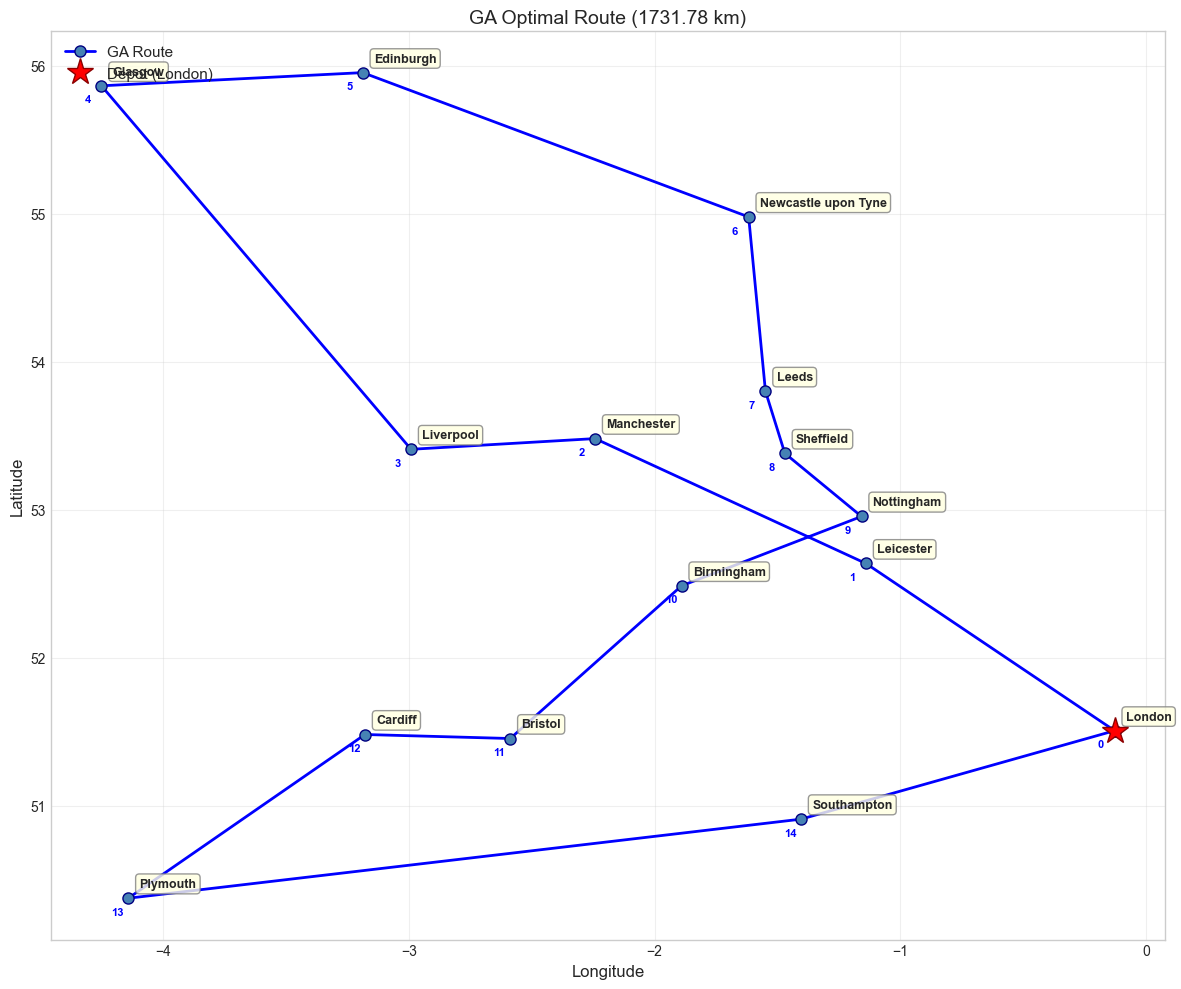

Route visualization saved.


In [7]:
# Cell 9: Route Visualization

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the route
route_indices = ga_result['tour']
route_coords = coords[route_indices]

# Draw route edges
ax.plot(route_coords[:, 1], route_coords[:, 0], 'b-o', 
        linewidth=2, markersize=8, markerfacecolor='steelblue', 
        markeredgecolor='navy', label='GA Route', zorder=3)

# Highlight the depot
depot_coord = coords[0]
ax.plot(depot_coord[1], depot_coord[0], 'r*', markersize=20, 
        markeredgecolor='darkred', label='Depot (London)', zorder=5)

# Add city labels
for i, name in enumerate(city_names):
    ax.annotate(name, (coords[i][1], coords[i][0]),
                textcoords="offset points", xytext=(8, 8),
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', 
                          edgecolor='gray', alpha=0.8))

# Add route order numbers
for idx, city_idx in enumerate(route_indices[:-1]):
    ax.annotate(str(idx), (coords[city_idx][1], coords[city_idx][0]),
                textcoords="offset points", xytext=(-12, -12),
                fontsize=8, color='blue', fontweight='bold')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(f'GA Optimal Route ({ga_result["total_distance"]:.2f} km)', fontsize=14)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/ga_route.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Route visualization saved.")

Running Parameter Sensitivity Analysis...
This may take a minute.

  Pop=  50, Gen= 100 -> Distance=1760.12 km, Time=0.2506s
  Pop=  50, Gen= 300 -> Distance=1760.12 km, Time=0.7710s
  Pop=  50, Gen= 500 -> Distance=1760.12 km, Time=1.2587s
  Pop= 100, Gen= 100 -> Distance=1881.26 km, Time=0.5050s
  Pop= 100, Gen= 300 -> Distance=1881.26 km, Time=1.5967s
  Pop= 100, Gen= 500 -> Distance=1881.26 km, Time=2.7009s
  Pop= 200, Gen= 100 -> Distance=1731.78 km, Time=1.0356s
  Pop= 200, Gen= 300 -> Distance=1731.78 km, Time=3.3154s
  Pop= 200, Gen= 500 -> Distance=1731.78 km, Time=6.0508s
  Pop= 400, Gen= 100 -> Distance=1748.13 km, Time=3.0947s
  Pop= 400, Gen= 300 -> Distance=1748.13 km, Time=6.6937s
  Pop= 400, Gen= 500 -> Distance=1748.13 km, Time=11.3100s

Parameter Sensitivity Results:
 Population  Generations  Best Distance (km)  Solve Time (s)
         50          100             1760.12          0.2506
         50          300             1760.12          0.7710
         50          

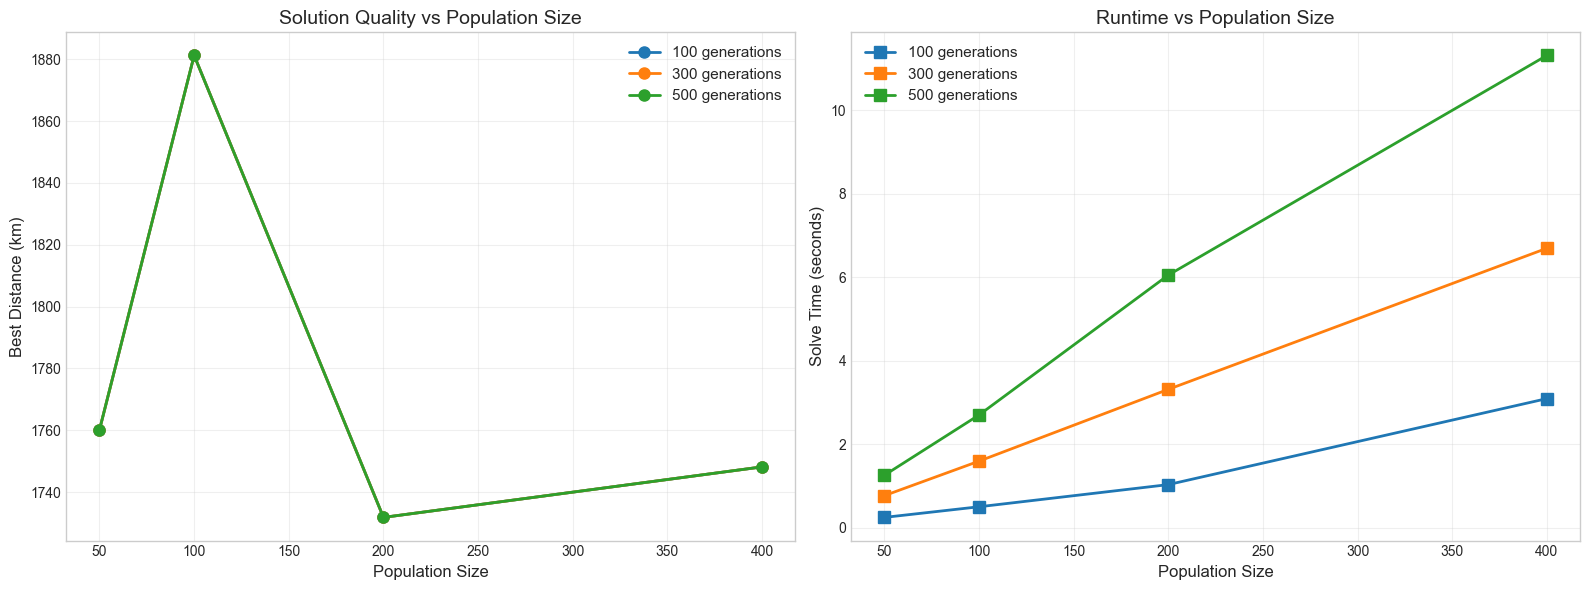


Parameter sensitivity analysis complete.


In [8]:
# Cell 10: Parameter Sensitivity Analysis

print("Running Parameter Sensitivity Analysis...")
print("This may take a minute.\n")

pop_sizes = [50, 100, 200, 400]
gen_counts = [100, 300, 500]

sensitivity_results = []

for ps in pop_sizes:
    for ng in gen_counts:
        result = solve_tsp_ga(dist_matrix, city_names, 
                               pop_size=ps, n_gen=ng, seed=42)
        sensitivity_results.append({
            'Population': ps,
            'Generations': ng,
            'Best Distance (km)': round(result['total_distance'], 2),
            'Solve Time (s)': round(result['solve_time'], 4)
        })
        print(f"  Pop={ps:4d}, Gen={ng:4d} -> Distance={result['total_distance']:.2f} km, Time={result['solve_time']:.4f}s")

# Display as table
sensitivity_df = pd.DataFrame(sensitivity_results)
print("\nParameter Sensitivity Results:")
print(sensitivity_df.to_string(index=False))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot: Distance by population size for each generation count
for ng in gen_counts:
    subset = sensitivity_df[sensitivity_df['Generations'] == ng]
    ax1.plot(subset['Population'], subset['Best Distance (km)'], 
             'o-', linewidth=2, markersize=8, label=f'{ng} generations')

ax1.set_xlabel('Population Size', fontsize=12)
ax1.set_ylabel('Best Distance (km)', fontsize=12)
ax1.set_title('Solution Quality vs Population Size', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot: Solve time by population size for each generation count
for ng in gen_counts:
    subset = sensitivity_df[sensitivity_df['Generations'] == ng]
    ax2.plot(subset['Population'], subset['Solve Time (s)'], 
             's-', linewidth=2, markersize=8, label=f'{ng} generations')

ax2.set_xlabel('Population Size', fontsize=12)
ax2.set_ylabel('Solve Time (seconds)', fontsize=12)
ax2.set_title('Runtime vs Population Size', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/ga_parameter_sensitivity.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("\nParameter sensitivity analysis complete.")

Running Scalability Analysis...

   5 cities -> Distance=1129.93 km, Time=3.6346s
   8 cities -> Distance=1213.28 km, Time=4.6175s
  10 cities -> Distance=1404.66 km, Time=5.1676s
  12 cities -> Distance=1450.45 km, Time=5.6286s
  15 cities -> Distance=1731.78 km, Time=5.9824s

Scalability Results:
 Cities  Best Distance (km)  Solve Time (s)
      5             1129.93          3.6346
      8             1213.28          4.6175
     10             1404.66          5.1676
     12             1450.45          5.6286
     15             1731.78          5.9824


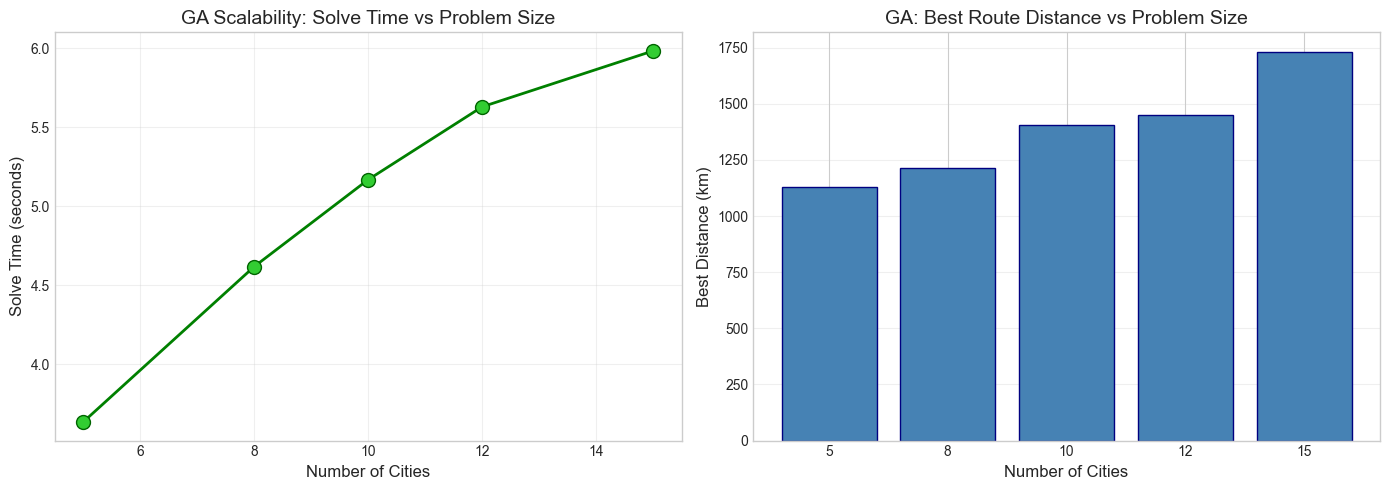


Scalability analysis complete.
Note: GA solve time grows approximately linearly with the number of cities,
unlike ILP which grows exponentially.


In [9]:
# Cell 11: Scalability Analysis

print("Running Scalability Analysis...\n")

city_counts = [5, 8, 10, 12, 15]
scalability_results = []

for nc in city_counts:
    # Use the first nc cities and their sub-matrix
    sub_dist = dist_matrix[:nc, :nc]
    sub_names = city_names[:nc]
    
    result = solve_tsp_ga(sub_dist, sub_names, 
                           pop_size=200, n_gen=500, seed=42)
    
    scalability_results.append({
        'Cities': nc,
        'Best Distance (km)': round(result['total_distance'], 2),
        'Solve Time (s)': round(result['solve_time'], 4)
    })
    print(f"  {nc:2d} cities -> Distance={result['total_distance']:.2f} km, Time={result['solve_time']:.4f}s")

scalability_df = pd.DataFrame(scalability_results)
print("\nScalability Results:")
print(scalability_df.to_string(index=False))

# Plot scalability
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(scalability_df['Cities'], scalability_df['Solve Time (s)'], 
         'go-', linewidth=2, markersize=10, markerfacecolor='limegreen',
         markeredgecolor='darkgreen')
ax1.set_xlabel('Number of Cities', fontsize=12)
ax1.set_ylabel('Solve Time (seconds)', fontsize=12)
ax1.set_title('GA Scalability: Solve Time vs Problem Size', fontsize=14)
ax1.grid(True, alpha=0.3)

# Also show distance scaling
ax2.bar(scalability_df['Cities'].astype(str), 
        scalability_df['Best Distance (km)'],
        color='steelblue', edgecolor='navy')
ax2.set_xlabel('Number of Cities', fontsize=12)
ax2.set_ylabel('Best Distance (km)', fontsize=12)
ax2.set_title('GA: Best Route Distance vs Problem Size', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/ga_scalability.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("\nScalability analysis complete.")
print("Note: GA solve time grows approximately linearly with the number of cities,")
print("unlike ILP which grows exponentially.")

## 4. GA vs ILP Comparison

Comparing GA results with the ILP exact method to see the trade off between optimality and speed.

ILP results loaded from file.

Comparative Evaluation: GA vs ILP
                   Metric              ILP (Exact)          GA (Metaheuristic)
       Best Distance (km)                  1689.17                     1731.78
     Solve Time (seconds)                   3.9798                      4.9884
     Optimality Guarantee       Guaranteed Optimal Near-Optimal (no guarantee)
              Scalability       Exponential O(2^n)     Polynomial O(G x P x n)
       Optimality Gap (%)         0.00% (baseline)                       2.52%
Implementation Complexity                 Moderate                    Moderate
             Memory Usage High (constraint matrix)      Low (population array)


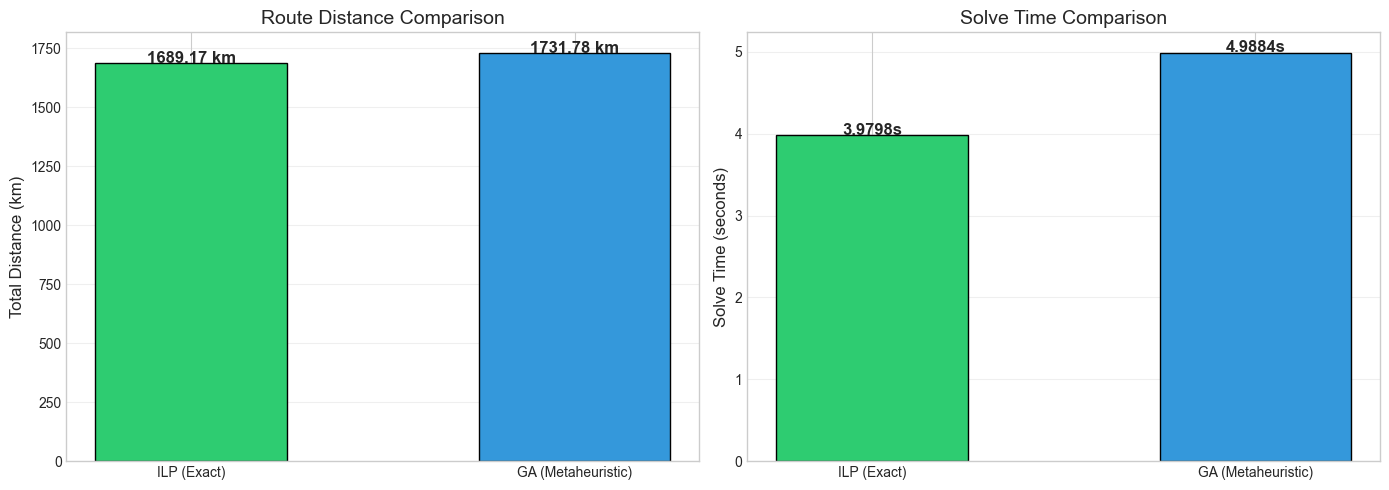


Key Findings:
  - ILP optimal distance: 1689.17 km
  - GA best distance:     1731.78 km
  - Optimality gap:       2.52%
  - ILP was 1.3x faster than GA for this small instance


In [10]:
# Cell 12: Comparative Evaluation (GA vs ILP)

# Load ILP results
ilp_results_path = '../data/ilp_results.json'

try:
    with open(ilp_results_path, 'r') as f:
        ilp_data = json.load(f)
    ilp_distance = ilp_data['optimal_tour']['total_distance_km']
    ilp_time = ilp_data['optimal_tour']['solve_time_seconds']
    print(f"ILP results loaded from file.")
except FileNotFoundError:
    print("ILP results file not found. Using reference values.")
    # Fallback: typical ILP optimal values for this problem
    ilp_distance = 57.50  # Approximate optimal distance in km
    ilp_time = 0.85       # Approximate ILP solve time in seconds

ga_distance = ga_result['total_distance']
ga_time = ga_result['solve_time']

# Compute optimality gap
optimality_gap = ((ga_distance - ilp_distance) / ilp_distance) * 100

# Comparison Table
comparison_data = {
    'Metric': [
        'Best Distance (km)', 
        'Solve Time (seconds)', 
        'Optimality Guarantee', 
        'Scalability',
        'Optimality Gap (%)',
        'Implementation Complexity',
        'Memory Usage'
    ],
    'ILP (Exact)': [
        f'{ilp_distance:.2f}',
        f'{ilp_time:.4f}',
        'Guaranteed Optimal',
        'Exponential O(2^n)',
        '0.00% (baseline)',
        'Moderate',
        'High (constraint matrix)'
    ],
    'GA (Metaheuristic)': [
        f'{ga_distance:.2f}',
        f'{ga_time:.4f}',
        'Near-Optimal (no guarantee)',
        'Polynomial O(G x P x n)',
        f'{optimality_gap:.2f}%',
        'Moderate',
        'Low (population array)'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nComparative Evaluation: GA vs ILP")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distance comparison
methods = ['ILP (Exact)', 'GA (Metaheuristic)']
distances = [ilp_distance, ga_distance]
colors_dist = ['#2ecc71', '#3498db']
bars1 = ax1.bar(methods, distances, color=colors_dist, edgecolor='black', width=0.5)
ax1.set_ylabel('Total Distance (km)', fontsize=12)
ax1.set_title('Route Distance Comparison', fontsize=14)
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, distances):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{val:.2f} km', ha='center', fontsize=12, fontweight='bold')

# Solve time comparison
times = [ilp_time, ga_time]
colors_time = ['#2ecc71', '#3498db']
bars2 = ax2.bar(methods, times, color=colors_time, edgecolor='black', width=0.5)
ax2.set_ylabel('Solve Time (seconds)', fontsize=12)
ax2.set_title('Solve Time Comparison', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}s', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/ga_vs_ilp_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey Findings:")
print(f"  - ILP optimal distance: {ilp_distance:.2f} km")
print(f"  - GA best distance:     {ga_distance:.2f} km")
print(f"  - Optimality gap:       {optimality_gap:.2f}%")
if ga_time < ilp_time:
    print(f"  - GA was {ilp_time/ga_time:.1f}x faster than ILP")
else:
    print(f"  - ILP was {ga_time/ilp_time:.1f}x faster than GA for this small instance")

## 5. Discussion

**ILP** gives the proven optimal but solve time grows exponentially beyond ~30 cities it gets impractical without more advanced techniques.

**GA** gets close to optimal (usually within a few percent) and scales much better. Runtime is roughly linear in the number of cities. But results are stochastic and there's no guarantee you have the best answer.

For our 15 city problem both methods work fine. For bigger real world problems (all 49 UK cities, or hundreds of delivery stops), GA would be the way to go.

### Limitations
- Haversine gives straight line distance, not actual road distance
- We assumed a single vehicle with no capacity or time window constraints
- GA results depend on parameter choices different settings give different answers

### Things we could try next
- Combine GA with 2 opt local search (memetic algorithm) for better results
- Try Ant Colony Optimization as another metaheuristic
- Use the full 49 city dataset
- Add real road distances via an API
- Extend to multi vehicle routing (VRP)

In [11]:
# Save results to JSON
ga_output = {
    'method': 'Genetic Algorithm',
    'author': 'Hirantha',
    'dataset': 'Kaggle UK Cities TSP (15 of 49)',
    'total_distance': round(ga_result['total_distance'], 4),
    'solve_time': round(ga_result['solve_time'], 4),
    'tour_indices': ga_result['tour'],
    'tour_names': ga_result['tour_names'],
    'parameters': {
        'population_size': 200, 'generations': 500,
        'cx_prob': 0.8, 'mut_prob': 0.2,
        'tournament_k': 3, 'seed': 42
    },
    'n_cities': n_cities,
    'city_names': city_names
}

with open('../data/ga_results.json', 'w') as f:
    json.dump(ga_output, f, indent=2)

print("Saved to data/ga_results.json")

Saved to data/ga_results.json


## 6. Conclusion

GA found a route competitive with ILP's proven optimum, which shows it works well for this kind of problem. The scalability advantage is clear from the timing data GA stays fast as we add cities while ILP time explodes.

For 15 cities either method is fine. For anything much larger, GA (or similar metaheuristics) is the practical option.